# 08 Permutation Test for Cross-Branch Combinations

**Methods mapping:** permutation test for cross-branch haplotype combinations.

This notebook builds sample-level branch combinations from the TreeCluster assignments, selects the most frequent exact cross-branch combination in each cohort, builds the eligible exact-combination family, and permutes branch labels within month-region strata.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'config' / 'analysis_config.yaml').exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / 'notebooks'))
import analysis_utils as au
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
rel = lambda path: Path(path).relative_to(ROOT).as_posix()
ROOT


PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes')

In [2]:
DATA_DIR, FIG_DIR = au.step_dirs('08_permutation_test_for_cross_branch_combinations', ROOT)
INPUTS = {
    "metadata": ROOT / "data/metadata/meta_v6_with_season_clade.csv",
    "AU_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1037681_extracted_4652-5617.fasta",
    "US_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1130896_extracted_4652-5617.fasta",
}
OUTPUTS = {
    "observed_combo_counts": DATA_DIR / "observed_treecluster_combo_counts.csv",
    "permutation_summary": DATA_DIR / "month_region_permutation_publication_summary.csv",
    "permutation_draws": DATA_DIR / "month_region_permutation_draws.csv",
    "all_combo_family": DATA_DIR / "all_eligible_exact_combo_family_results.csv",
    "figure_png": FIG_DIR / "Fig3EF_cross_branch_permutation.png",
    "figure_pdf": FIG_DIR / "Fig3EF_cross_branch_permutation.pdf",
    "figure_svg": FIG_DIR / "Fig3EF_cross_branch_permutation.svg",
}


def show_paths(title, paths):
    rows = []
    for name, path in paths.items():
        path = Path(path)
        rows.append({"name": name, "relative_path": rel(path), "exists": path.exists()})
    display(Markdown(f"### {title}"))
    display(pd.DataFrame(rows))

for path in OUTPUTS.values():
    Path(path).parent.mkdir(parents=True, exist_ok=True)

show_paths("Input paths", INPUTS)
show_paths("Output paths", OUTPUTS)
DATA_DIR, FIG_DIR


### Input paths

,name,relative_path,exists
0,metadata,data/metadata/meta_v6_with_season_clade.csv,True
1,AU_haplotype_fasta,data/input/haplotypes/PRJNA1037681_...,True
2,US_haplotype_fasta,data/input/haplotypes/PRJNA1130896_...,True


### Output paths

,name,relative_path,exists
0,observed_combo_counts,data/processed_data/08_permutation_test_...,True
1,permutation_summary,data/processed_data/08_permutation_test_...,True
2,permutation_draws,data/processed_data/08_permutation_test_...,True
3,all_combo_family,data/processed_data/08_permutation_test_...,True
4,figure_png,results/figures/08_permutation_test...,True
5,figure_pdf,results/figures/08_permutation_test...,True
6,figure_svg,results/figures/08_permutation_test...,True


(PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/data/processed_data/08_permutation_test_for_cross_branch_combinations'),
 PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/results/figures/08_permutation_test_for_cross_branch_combinations'))

## Rebuild Observed Branch Combinations

The permutation target is selected from the observed branch-combination table, not from a fixed manuscript table.


In [3]:
branch_combos, assignments, tree_manifest = au.get_sample_branch_combinations(ROOT)
targets = au.select_target_branch_combos(ROOT)
observed_preview = branch_combos.groupby(['project', 'project_label', 'TreeCluster_combo'], as_index=False).agg(samples=('SampleID', 'nunique')).sort_values(['project', 'samples'], ascending=[True, False])

display(tree_manifest)
display(targets)
display(observed_preview.head(12))


,project,project_label,input_haplotype_fasta,treefile,treecluster_output,treecluster_threshold,status
0,PRJNA1037681,Australia,data/input/haplotypes/PRJNA1037681_...,data/processed_data/treecluster_cache...,data/processed_data/treecluster_cache...,0.010,verified_cache_from_input_haplotype_fasta
1,PRJNA1130896,United States,data/input/haplotypes/PRJNA1130896_...,data/processed_data/treecluster_cache...,data/processed_data/treecluster_cache...,0.015,verified_cache_from_input_haplotype_fasta


,project,project_label,target_combo,target_branches,n_target_samples,selection_rule
0,PRJNA1037681,Australia,C4+C6,"[C4, C6]",23,most frequent exact cross-branch TreeCluster c...
1,PRJNA1130896,United States,C18+C21,"[C18, C21]",26,most frequent exact cross-branch TreeCluster c...


,project,project_label,TreeCluster_combo,samples
4,PRJNA1037681,Australia,C4+C6,23
3,PRJNA1037681,Australia,C3,5
5,PRJNA1037681,Australia,C5+C6,2
6,PRJNA1037681,Australia,C6,2
7,PRJNA1037681,Australia,C6+C7,2
0,PRJNA1037681,Australia,C1+C4+C6,1
1,PRJNA1037681,Australia,C1+C6,1
2,PRJNA1037681,Australia,C2,1
18,PRJNA1130896,United States,C18+C21,26
22,PRJNA1130896,United States,C21,5


## Run Stratified Permutation

By default this runs 20,000 permutations. For a quick smoke test, set `RSVA_N_PERMUTATIONS` before running the notebook.


In [4]:
observed, summary, draws = au.cross_branch_permutation(ROOT, DATA_DIR)

display(observed.sort_values(['project', 'n_samples'], ascending=[True, False]).head(12))
display(summary)
display(draws.head())


,project,project_label,TreeCluster_combo,n_samples,median_n_haplotypes,median_n_branches,is_target_combo
4,PRJNA1037681,Australia,C4+C6,23,2.0,2.0,True
3,PRJNA1037681,Australia,C3,5,2.0,1.0,False
5,PRJNA1037681,Australia,C5+C6,2,2.0,2.0,False
6,PRJNA1037681,Australia,C6,2,1.5,1.0,False
7,PRJNA1037681,Australia,C6+C7,2,2.0,2.0,False
0,PRJNA1037681,Australia,C1+C4+C6,1,3.0,3.0,False
1,PRJNA1037681,Australia,C1+C6,1,2.0,2.0,False
2,PRJNA1037681,Australia,C2,1,2.0,1.0,False
18,PRJNA1130896,United States,C18+C21,26,2.0,2.0,True
22,PRJNA1130896,United States,C21,5,2.0,1.0,False


,project,project_label,target_combo,analysis_mode,stratification,n_permutations,n_samples,n_haplotypes,n_exchangeability_strata,n_eligible_exact_cross_cluster_combos,n_observed_cross_cluster_combos,observed_target_count,observed_max_all_eligible_count,target_null_mean,target_null_sd,target_null_q025,target_null_median,target_null_q975,target_observed_expected_ratio,target_unadjusted_p_count,target_z,all_eligible_max_count_null_mean,all_eligible_max_count_null_q025,all_eligible_max_count_null_median,all_eligible_max_count_null_q975,all_eligible_max_count_adjusted_p,all_eligible_maxT_null_q025,all_eligible_maxT_null_median,all_eligible_maxT_null_q975,all_eligible_maxT_adjusted_p
0,PRJNA1037681,Australia,C4+C6,month_region_all_eligible_exact_combo,year_month + geo_stratum,20000,37,72,4,29,5,23,23,10.6557,2.335842,6.0,11.0,15.0,2.158469,0.00005,5.284733,10.66135,6.0,11.0,15.0,0.00005,1.506082,2.458810,9.417330,0.072146
1,PRJNA1130896,United States,C18+C21,month_region_all_eligible_exact_combo,year_month + geo_stratum,20000,72,144,10,667,1,26,26,9.2311,2.279713,5.0,9.0,14.0,2.816566,0.00005,7.355706,9.23255,5.0,9.0,14.0,0.00005,5.486752,13.508747,44.710178,0.862207


,project,project_label,target_combo,iteration,permuted_target_count,permuted_max_all_eligible_exact_combo_count,permuted_max_all_eligible_exact_combo_z
0,PRJNA1037681,Australia,C4+C6,1,13,13,1.705188
1,PRJNA1037681,Australia,C4+C6,2,12,12,12.764577
2,PRJNA1037681,Australia,C4+C6,3,15,15,2.558284
3,PRJNA1037681,Australia,C4+C6,4,13,13,3.656202
4,PRJNA1037681,Australia,C4+C6,5,11,11,3.647760


## Figure

Fig. 3E-F is drawn from the regenerated null draws and summary statistics.


/root/autodl-tmp/rsva-g-intrahost-haplotypes/notebooks/analysis_utils.py:1669: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


{'png': 'results/figures/08_permutation_test_for_cross_branch_combinations/Fig3EF_cross_branch_permutation.png',
 'pdf': 'results/figures/08_permutation_test_for_cross_branch_combinations/Fig3EF_cross_branch_permutation.pdf',
 'svg': 'results/figures/08_permutation_test_for_cross_branch_combinations/Fig3EF_cross_branch_permutation.svg'}

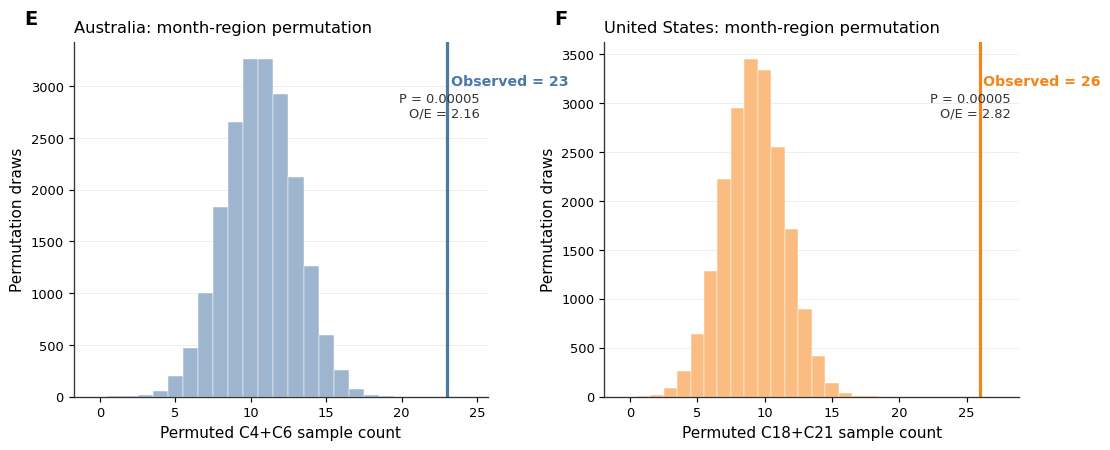

In [5]:
fig, paths = au.draw_permutation(summary, draws, FIG_DIR)
display(paths)
plt.show()
